In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
from sklearn.datasets import load_iris

In [3]:
d = load_iris(as_frame=True)

In [4]:
data = d.data

In [5]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
data = data.rename(columns={'sepal length (cm)': 'sepal_length(cm)', 'sepal width (cm)':'sepal_width(cm)',
                    'petal length (cm)': 'petal_length(cm)', 'petal width (cm)': 'petal_width(cm)'})

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sepal_length(cm)  150 non-null    float64
 1   sepal_width(cm)   150 non-null    float64
 2   petal_length(cm)  150 non-null    float64
 3   petal_width(cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [8]:
target = d.target

In [9]:
target_names = d.target_names # 'setosa', 'versicolor', 'virginica'

In [10]:
feature_names = d.feature_names # sepal_length(cm) sepal_width(cm) petal_length(cm) petal_width(cm)

In [11]:
data['target'] = target

In [12]:
data.head()

,sepal_length(cm),sepal_width(cm),petal_length(cm),petal_width(cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
setosa = data[data.target == 0] # setosa

In [14]:
versicolor = data[data.target == 1] # versicolor

In [15]:
virginica = data[data.target == 2] # virginica

In [16]:
data['flower_name'] = data.target.apply(lambda x: d.target_names[x])
data.head()

,sepal_length(cm),sepal_width(cm),petal_length(cm),petal_width(cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [17]:
data_0 = data[:50] # setosa 
data_1 = data[50:100] # versicolor
data_2 = data[100:] # virginica

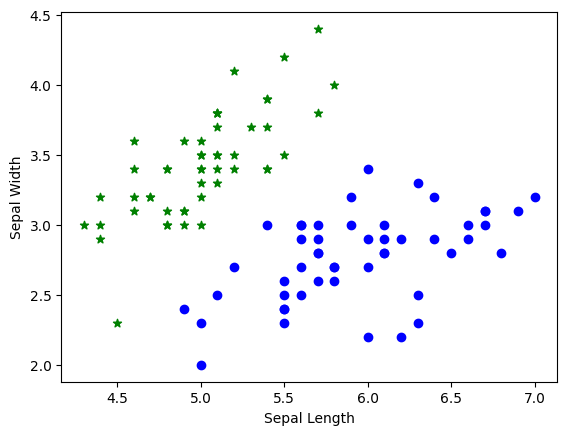

In [18]:
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.scatter(data_0['sepal_length(cm)'], data_0['sepal_width(cm)'], color= "green", marker='*')
plt.scatter(data_1['sepal_length(cm)'], data_1['sepal_width(cm)'], color= "blue", marker='o') 
plt.show()

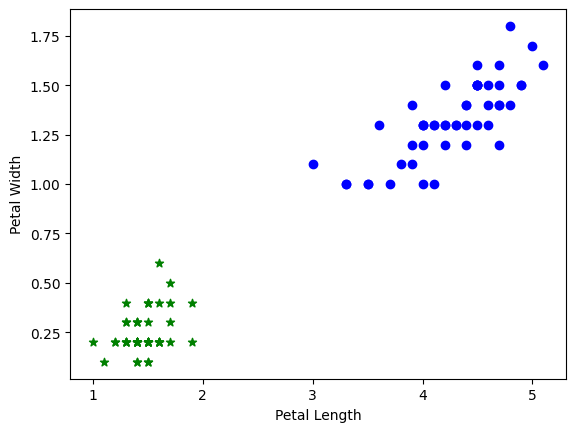

In [19]:
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.scatter(data_0['petal_length(cm)'], data_0['petal_width(cm)'], color= "green", marker='*')
plt.scatter(data_1['petal_length(cm)'], data_1['petal_width(cm)'], color= "blue", marker='o') 
plt.show()

In [20]:
data.head()

,sepal_length(cm),sepal_width(cm),petal_length(cm),petal_width(cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [21]:
X = data.drop(columns=['target','flower_name'], axis=1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [23]:
svm.score(X_test, y_test)

0.9666666666666667

In [24]:
X_test.head()

,sepal_length(cm),sepal_width(cm),petal_length(cm),petal_width(cm)
64,5.6,2.9,3.6,1.3
34,4.9,3.1,1.5,0.2
142,5.8,2.7,5.1,1.9
71,6.1,2.8,4.0,1.3
90,5.5,2.6,4.4,1.2


In [25]:
svm.predict([[4.8, 3.0, 1.5, 0.3]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [26]:
svm.predict([[6.7, 3.0, 5.2, 2.3]]) # 6.7 3.0 5.2 2.3	

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([2])

#### Tuning parameters

#### 1. Regularization (C)

In [27]:
model_svm_c = SVC(C=1)
model_svm_c.fit(X_train, y_train)
model_svm_c.score(X_test, y_test)

0.9666666666666667

In [28]:
model_svm_c = SVC(C=10)
model_svm_c.fit(X_train, y_train)
model_svm_c.score(X_test, y_test)

0.9666666666666667

#### 2. Gamma

In [29]:
model_svm_gamma = SVC(gamma= 10)
model_svm_gamma.fit(X_train, y_train)
model_svm_gamma.score(X_test, y_test)

0.9333333333333333

#### 3. Kernel Linear

In [30]:
model_linear_kernel = SVC(kernel='linear')
model_linear_kernel.fit(X_train, y_train)
model_linear_kernel.score(X_test, y_test)

0.9666666666666667

#### 4. Kernel  Rbf

In [32]:
model_rbf_kernel = SVC(kernel='rbf')
model_rbf_kernel.fit(X_train, y_train)
model_rbf_kernel.score(X_test, y_test)

0.9666666666666667